# Logistic Regression 2
## Predictive models

We know that a good infrence model is not necessarily the best predictive model. Here we will compare both cases, using the inference model we identified previously and a naive predictive model on the raw data

In [9]:
import sys
sys.path.append("../src")
from models.logistic.prediction import run_logistic_pipeline
import pandas as pd
from sklearn.model_selection import train_test_split
from models.utils.display_results import display_model_results

### Prediction on raw data


MODEL RESULTS: Logistic Regression

Metrics:


,accuracy,precision,recall,f1,auc
train,0.8536,0.8000,0.7273,0.7619,0.9052
test,0.8167,0.7857,0.5789,0.6667,0.8588


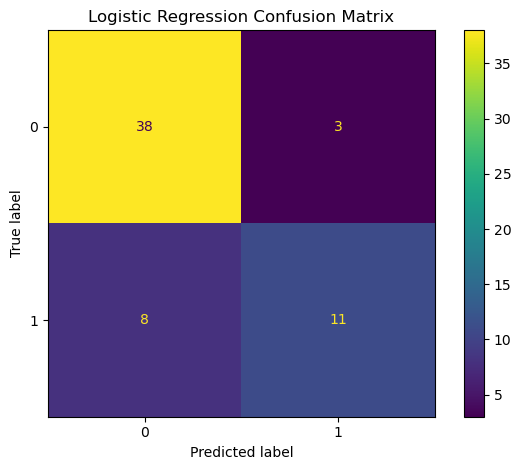

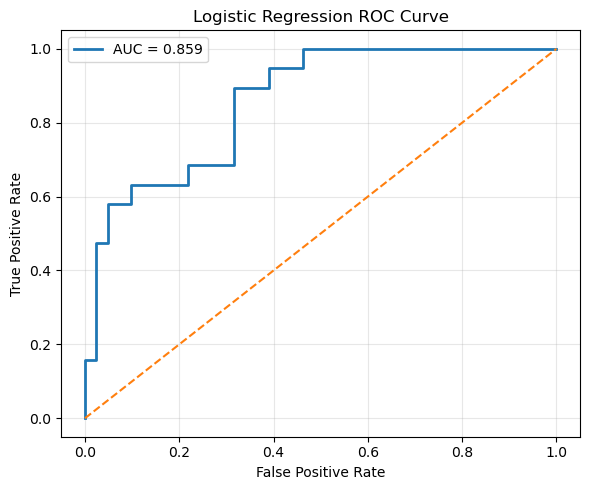

In [14]:
# Dataset with no processing nor feature selection
df_raw = pd.read_csv("../data/raw/heart_failure_clinical_records_dataset.csv")
X_raw = df_raw.drop(columns=["DEATH_EVENT"])
y_raw = df_raw["DEATH_EVENT"]
# Splitting the dataset into training and testing sets
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
# We fit de logit model
logit_raw_results = run_logistic_pipeline(X_train_raw,
 X_test_raw, 
 y_train_raw, 
 y_test_raw
 )

display_model_results(logit_raw_results)

### Prediction based on the inference model


MODEL RESULTS: Logistic Regression

Metrics:


,accuracy,precision,recall,f1,auc
train,0.8452,0.7778,0.7273,0.7517,0.9015
test,0.8167,0.7857,0.5789,0.6667,0.8896


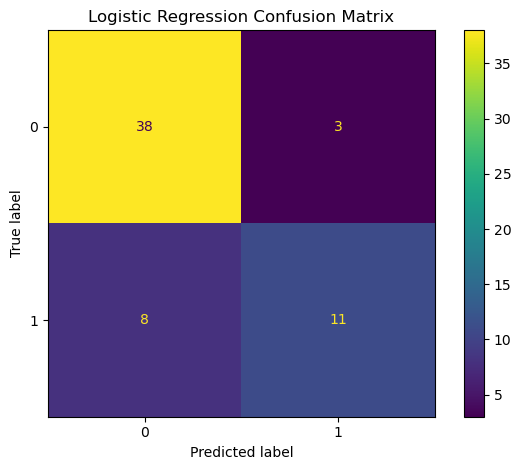

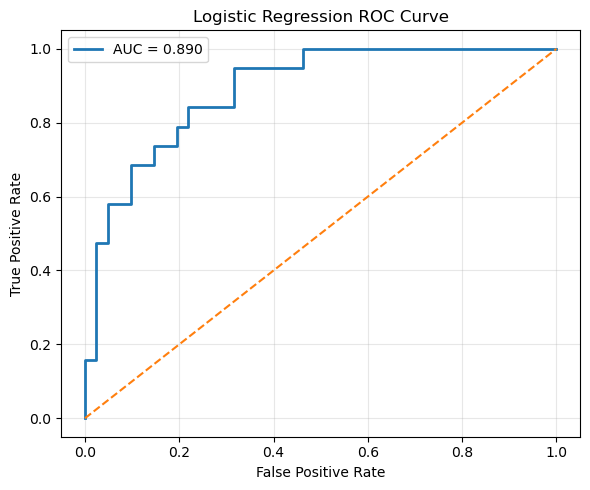

In [13]:
# Dataset with no processing nor feature selection
df_processed = pd.read_csv("../data/processed/heart_failure_clinical_records_dataset_processed.csv")

# Selected features
features = ["time", "age_centered", "ejection_fraction_centered", "sodium_creatinine_interaction"]
X_processed = df_processed[features]
y_processed = df_processed["DEATH_EVENT"]

# Splitting the dataset into training and testing sets
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)
# We fit de logit model
logit_processed_results = run_logistic_pipeline(X_train_processed,
 X_test_processed, 
 y_train_processed, 
 y_test_processed)

display_model_results(logit_processed_results)